# Statistiques descriptives

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## Description détaillée des variables de `heart.txt`

---

### 1. `age` — Âge du patient
- **Type** : Quantitative continue
- **Unité** : années
- **Plage observée** : 29 à 77 ans
- **Rôle** : facteur de risque classique des maladies cardiovasculaires — plus l'âge augmente, plus le risque tend à s'élever
- **Usage analytique** : peut être utilisée brute ou discrétisée en tranches (< 45, 45–60, > 60)

---

### 2. `sexe` — Sexe du patient
- **Type** : Qualitative nominale binaire
- **Modalités** : `masculin` / `feminin`
- **Rôle** : variable socio-démographique ; les hommes présentent statistiquement un risque cardiovasculaire plus élevé, surtout avant 60 ans
- **Usage analytique** : variable de stratification, test du Chi² avec `coeur`

---

### 3. `typedouleur` — Type de douleur thoracique
- **Type** : Qualitative ordinale
- **Modalités** : `A`, `B`, `C`, `D`
  - **A** : angine de poitrine typique (douleur à l'effort, soulagée au repos)
  - **B** : angine atypique
  - **C** : douleur non angineuse
  - **D** : asymptomatique (aucune douleur)
- **Rôle** : indicateur clinique fort — paradoxalement, le type D (asymptomatique) est souvent associé à une maladie cardiaque silencieuse mais sévère
- **Usage analytique** : test du Chi², tableau de contingence avec `coeur`

---

### 4. `sucre` — Glycémie à jeun
- **Type** : Qualitative nominale binaire
- **Modalités** :
  - `A` : glycémie ≤ 120 mg/dl (normale)
  - `B` : glycémie > 120 mg/dl (élevée, signe possible de diabète)
- **Rôle** : le diabète est un facteur de risque cardiovasculaire majeur ; une glycémie élevée endommage les vaisseaux sanguins
- **Usage analytique** : test du Chi² avec `coeur`

---

### 5. `tauxmax` — Fréquence cardiaque maximale atteinte
- **Type** : Quantitative continue
- **Unité** : battements par minute (bpm)
- **Plage observée** : 71 à 202 bpm
- **Rôle** : mesurée lors d'un test d'effort ; une fréquence maximale **basse** peut indiquer une capacité cardiaque réduite et est souvent associée à une maladie coronarienne
- **Usage analytique** : boxplot par groupe `coeur`, corrélation avec `age`, test de Student

---

### 6. `angine` — Angine induite par l'effort
- **Type** : Qualitative nominale binaire
- **Modalités** : `oui` / `non`
- **Rôle** : indique si le patient a ressenti une douleur thoracique **pendant l'épreuve d'effort** ; une réponse positive est un signal d'alerte clinique sérieux
- **Usage analytique** : test du Chi² avec `coeur`, croisement avec `typedouleur`

---

### 7. `depression` — Dépression du segment ST
- **Type** : Quantitative continue
- **Unité** : dixièmes de millivolt (sur l'ECG)
- **Plage observée** : 0 à 62
- **Rôle** : mesure l'abaissement du segment ST sur l'électrocardiogramme par rapport au repos — une valeur élevée traduit un **manque d'oxygénation du muscle cardiaque** (ischémie) et est fortement associée à la maladie coronarienne
- **Usage analytique** : variable quantitative clé, boxplot par groupe `coeur`, corrélation, seuil de détection

---

### 8. `coeur` — Présence de maladie cardiaque *(variable cible)*
- **Type** : Qualitative nominale binaire
- **Modalités** : `presence` / `absence`
- **Rôle** : c'est la **variable à expliquer** (ou à prédire) — elle indique si le patient a été diagnostiqué avec une maladie cardiaque
- **Usage analytique** : variable dépendante dans tous les tests bivariés et les modèles de classification


In [9]:
dataset = pd.read_csv('heart.txt', sep='\t')
dataset.head()

,age,sexe,typedouleur,sucre,tauxmax,angine,depression,coeur
0,70,masculin,D,A,109,non,24,presence
1,67,feminin,C,A,160,non,16,absence
2,57,masculin,B,A,141,non,3,presence
3,64,masculin,D,A,105,oui,2,absence
4,74,feminin,B,A,121,oui,2,absence


## Quelques manipulations

Équivalents du filtrage de lignes / sélection d'un échantillon.

In [10]:
# filtrage booléen
plus = dataset[dataset['age'] > 40]

# conditions combinées
sel = dataset[(dataset['age'] < 60) & (dataset['tauxmax'] > 139)]

#  filtre sur une modalité
femmes = dataset[dataset['sexe'] == 'feminin']

# Sélection d'un échantillon : une ligne sur deux
echantillon = dataset.iloc[0:100:2]

len(plus), len(sel), len(femmes), len(echantillon)

(255, 144, 87, 50)

---
# Univariée

## Cas discret

On travaille sur une variable quantitative discrète (ici `age`).

In [11]:
data = dataset['age']

### Tableau des effectifs

In [22]:
eff = data.value_counts().sort_index()
eff.head()

age
29    1
34    2
35    3
37    2
38    1
Name: count, dtype: int64

### Tableau des effectifs cumulés

In [23]:
eff_cum = eff.cumsum()
eff_cum.head()

age
29    1
34    3
35    6
37    8
38    9
Name: count, dtype: int64

### Tableau des fréquences

In [24]:
eff_freq = eff / eff.sum()
eff_freq.head()

age
29    0.003704
34    0.007407
35    0.011111
37    0.007407
38    0.003704
Name: count, dtype: float64

### Tableau des fréquences cumulées

In [25]:
eff_freq_cum = eff_freq.cumsum()
eff_freq_cum.head()

age
29    0.003704
34    0.011111
35    0.022222
37    0.029630
38    0.033333
Name: count, dtype: float64

### Diagramme en bâtons des effectifs

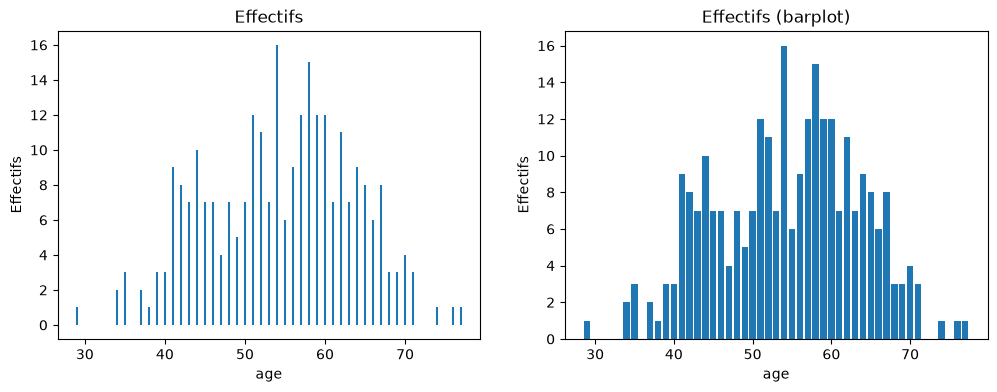

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].vlines(eff.index, 0, eff.values)   # type='h'
ax[0].set(xlabel='age', ylabel='Effectifs', title='Effectifs')

ax[1].bar(eff.index, eff.values)         # barplot
ax[1].set(xlabel='age', ylabel='Effectifs', title='Effectifs (barplot)')
plt.show()

### Fonction de répartition
La **fonction de répartition** (ou *Cumulative Distribution Function* — CDF) d'une variable aléatoire X est définie par :

> **F(x) = P(X ≤ x)**

Elle donne, pour chaque valeur *x*, la **probabilité que la variable aléatoire soit inférieure ou égale à x**.

- *Quelle est la probabilité qu'un client attende moins de 5 minutes ?* → F(5)
- *Quelle est la proba qu'un produit tombe en panne avant 1000 heures ?* → F(1000)

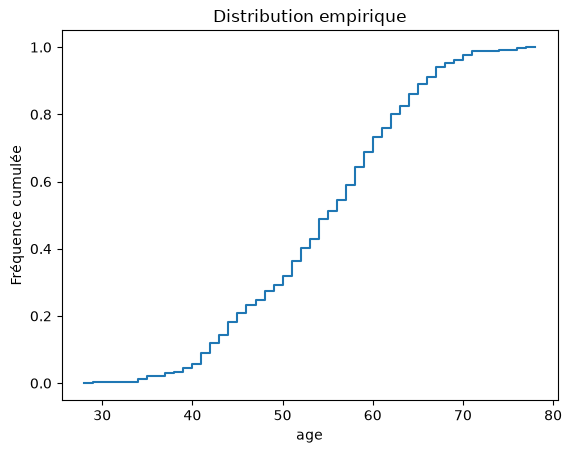

In [5]:
x = np.concatenate(([data.min() - 1], eff_freq_cum.index.values, [data.max() + 1]))
y = np.concatenate(([0], eff_freq_cum.values, [1]))

plt.step(x, y, where='post')
plt.xlabel('age'); plt.ylabel('Fréquence cumulée'); plt.title('Distribution empirique')
plt.show()

### Boxplot
Le **boxplot** (ou *boîte à moustaches*) est une représentation graphique qui résume la distribution d'une variable quantitative à partir de **5 statistiques clés**.
#### 1. Où se situe le centre de la distribution ?
→ La **médiane** (trait central dans la boîte) indique la valeur centrale, sans être influencée par les extrêmes.

#### 2. Quelle est la dispersion des données ?
→ Plus la boîte et les moustaches sont **larges**, plus les données sont dispersées.

#### 3. La distribution est-elle symétrique ou asymétrique ?
- Médiane **centrée** dans la boîte → distribution symétrique
- Médiane **proche de Q1** → asymétrie à droite (queue vers les grandes valeurs)
- Médiane **proche de Q3** → asymétrie à gauche (queue vers les petites valeurs)

#### 4. Y a-t-il des valeurs aberrantes ?
→ Les points isolés au-delà des moustaches signalent des **outliers** à investiguer.

#### 5. Comment comparer plusieurs groupes ?
→ C'est l'usage le plus puissant : **juxtaposer plusieurs boxplots** permet de comparer instantanément des distributions (ex : salaires par secteur, notes par classe, délais par région).


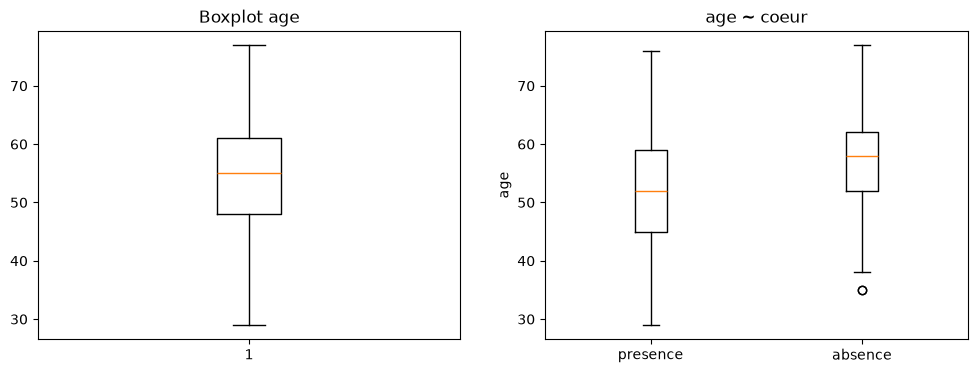

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].boxplot(data)
ax[0].set_title('Boxplot age')

groupes = [g['age'].values for _, g in dataset.groupby('coeur')]
ax[1].boxplot(groupes, tick_labels=dataset['coeur'].unique())
ax[1].set(title='age ~ coeur', ylabel='age')
plt.show()

#### 1. Résultat contre-intuitif : les malades sont plus jeunes
- La médiane du groupe `presence` (≈ 52 ans) est **inférieure** à celle du groupe
  `absence` (≈ 58 ans)
- C'est surprenant : dans cet échantillon, la maladie cardiaque ne touche pas
  prioritairement les plus âgés

#### 2. Le groupe `presence` est plus dispersé
- L'IQR de `presence` (≈ 14 ans) est plus large que celui de `absence` (≈ 10 ans)
- La moustache basse de `presence` descend jusqu'à ≈ 29 ans → des patients très
  jeunes sont malades
- La maladie cardiaque peut frapper à **tout âge** dans ce groupe

#### 3. Le groupe `absence` est plus homogène et plus âgé
- Les patients sans maladie sont concentrés entre 52 et 62 ans
- Un seul outlier à ≈ 35 ans : un patient très jeune sans maladie, ce qui est attendu

#### 4. Les boîtes se chevauchent largement
- Les deux distributions se superposent considérablement
- L'âge **seul** ne suffit pas à discriminer les deux groupes
- Il faudra combiner `age` avec d'autres variables pour construire un modèle
  prédictif efficace

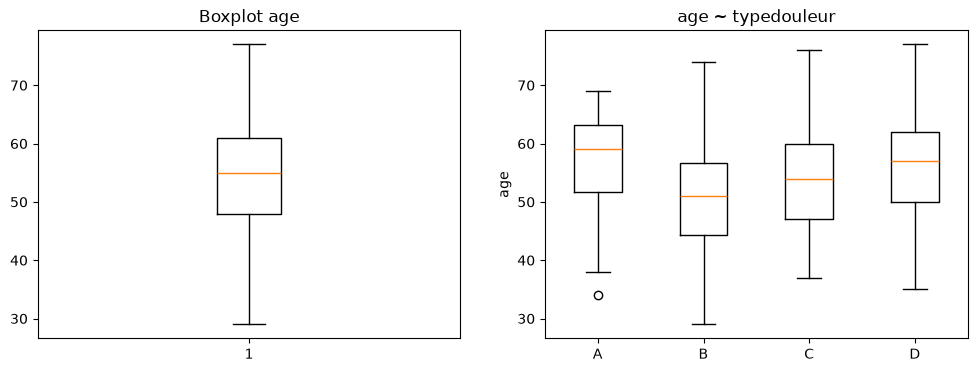

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].boxplot(data)
ax[0].set_title('Boxplot age')

groupes = [g['age'].values for _, g in dataset.groupby('typedouleur', sort=True)]
labels = dataset.groupby('typedouleur', sort=True).groups.keys()
ax[1].boxplot(groupes, tick_labels=labels)
ax[1].set(title='age ~ typedouleur', ylabel='age')
plt.show()

### Caractéristiques de position
#### Le mode

In [30]:
mode = eff[eff == eff.max()].index.tolist()

In [7]:
# Quantiles          (R : quantile(data, c(0.25, 0.5, 0.75)))
quantiles = data.quantile([0.25, 0.5, 0.75])

# Médiane (= quantile 0.5, non sensible aux valeurs aberrantes)
mediane = data.median()

# Moyenne (sensible aux valeurs aberrantes)
moyenne = data.mean()

print('Mode    :', mode)
print('Médiane :', mediane)
print('Moyenne :', moyenne)
print(quantiles)

# Résumé             (R : summary(data))
data.describe()

Mode    : [54]
Médiane : 55.0
Moyenne : 54.43333333333333
0.25    48.0
0.50    55.0
0.75    61.0
Name: age, dtype: float64


count    270.000000
mean      54.433333
std        9.109067
min       29.000000
25%       48.000000
50%       55.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64

### Caractéristiques de dispersion

In [8]:
n = len(data)

# Étendue                       (R : diff(range(data)))
etendue = data.max() - data.min()

# Étendue interquartile         (R : IQR(data))
iqr = data.quantile(0.75) - data.quantile(0.25)

# Variance non corrigée (moment centré d'ordre 2, ddof=0)
var_non_corr = data.var(ddof=0)

# Variance corrigée             (R : var(data), ddof=1)
var_corr = data.var(ddof=1)

# Écart-type corrigé            (R : sd(data))
ecart_type = data.std(ddof=1)

# Coefficient de variation (% de dispersion autour de la moyenne)
cv = np.sqrt(var_non_corr) / data.mean() * 100

print(f'Étendue              : {etendue}')
print(f'IQR                  : {iqr}')
print(f'Variance non corrigée: {var_non_corr:.3f}')
print(f'Variance corrigée    : {var_corr:.3f}')
print(f'Écart-type           : {ecart_type:.3f}')
print(f'CV                   : {cv:.2f} %')

Étendue              : 48
IQR                  : 13.0
Variance non corrigée: 82.668
Variance corrigée    : 82.975
Écart-type           : 9.109
CV                   : 16.70 %


### Caractéristiques de forme

R utilise le package `moments`. En Python : `scipy.stats`.

In [9]:
k = 3

# Moment d'ordre k              (R : moment(data, order=k))
moment_k = np.mean(data**k)

# Moment centré d'ordre k       (R : moment(data, order=k, central=TRUE))
moment_central_k = np.mean((data - data.mean())**k)

# Coefficient d'asymétrie de Fisher  (R : skewness)
# négatif -> distribution asymétrique à droite
asymetrie = stats.skew(data)

# Coefficient d'aplatissement de Pearson (R : kurtosis)
# scipy renvoie l'excès de kurtosis ; fisher=False -> kurtosis de Pearson comme R
aplatissement = stats.kurtosis(data, fisher=False)

print(f'Moment ordre {k}        : {moment_k:.2f}')
print(f'Moment centré ordre {k} : {moment_central_k:.2f}')
print(f'Asymétrie (skewness)  : {asymetrie:.4f}')
print(f'Aplatissement (kurt.) : {aplatissement:.4f}')

Moment ordre 3        : 174662.66
Moment centré ordre 3 : -122.29
Asymétrie (skewness)  : -0.1627
Aplatissement (kurt.) : 2.4431


## Cas continu

Regroupement en classes (règle de Sturges), histogramme, polygone et caractéristiques pondérées.

In [10]:
data = dataset['tauxmax']

# Nombre de classes — règle de Sturges  (R : log(length, 2) + 1, arrondi sup.)
import math
k_sturges = math.ceil(math.log2(len(data)) + 1)
print('Nombre de classes (Sturges) :', k_sturges)

# Histogramme + bornes/effectifs       (R : hist(data) ; graphique$mids/$counts)
counts, breaks = np.histogram(data, bins='sturges')
mids = (breaks[:-1] + breaks[1:]) / 2   # centres de classes

pd.DataFrame({'mids': mids, 'counts': counts})

Nombre de classes (Sturges) : 10


,mids,counts
0,77.55,1
1,90.65,5
2,103.75,11
3,116.85,23
4,129.95,31
5,143.05,45
6,156.15,71
7,169.25,54
8,182.35,24
9,195.45,5


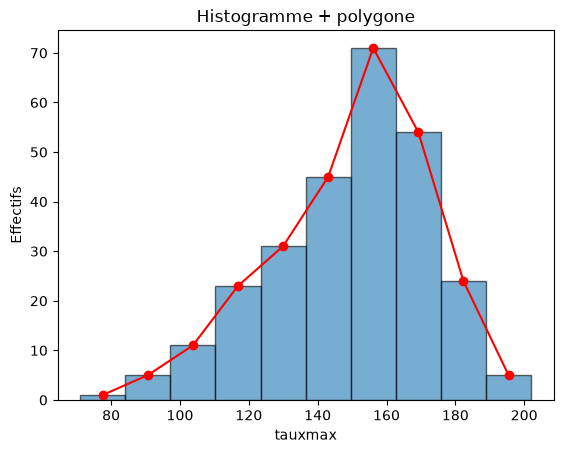

In [11]:
# Histogramme + polygone des effectifs  (R : hist + lines/points sur mids/counts)
plt.hist(data, bins=breaks, edgecolor='black', alpha=0.6)
plt.plot(mids, counts, color='red', marker='o')   # polygone des effectifs
plt.xlabel('tauxmax'); plt.ylabel('Effectifs'); plt.title('Histogramme + polygone')
plt.show()

In [12]:
# Déregroupement d'une distribution empirique (R : rep(mids, counts))
data_regroupee = np.repeat(mids, counts)

# Caractéristiques pondérées à partir des classes (R : Hmisc::wtd.mean/var/quantile)
def wtd_mean(x, w):
    return np.average(x, weights=w)

def wtd_var(x, w):
    m = wtd_mean(x, w)
    return np.average((x - m)**2, weights=w)

def wtd_quantile(x, w, probs):
    order = np.argsort(x)
    x, w = np.array(x)[order], np.array(w)[order]
    cw = np.cumsum(w) - 0.5 * w
    cw /= np.sum(w)
    return np.interp(probs, cw, x)

print('Moyenne pondérée  :', wtd_mean(mids, counts))
print('Variance pondérée :', wtd_var(mids, counts))
print('Quantiles pond.  :', wtd_quantile(mids, counts, [0.25, 0.5, 0.75]))

Moyenne pondérée  : 149.6485185185185
Variance pondérée : 534.8488126200273
Quantiles pond.  : [134.08684211 152.42327586 166.8396    ]


## Cas caractère qualitatif

Tableau de contingence (effectifs par modalité).

In [13]:
# R : table(data)
dataset['typedouleur'].value_counts()

typedouleur
D    129
C     79
B     42
A     20
Name: count, dtype: int64

---
# Bivariée

## Tableau de contingence et distributions

On croise deux variables qualitatives (`sexe` × `coeur`).

In [14]:
data1 = dataset['sexe']
data2 = dataset['coeur']

# Tableau de contingence        (R : table(data1, data2))
cont = pd.crosstab(data1, data2)
print('Contingence :')
print(cont)

# Distribution jointe avec totaux (R : addmargins)
joint = pd.crosstab(data1, data2, margins=True, margins_name='Sum')
print('\nJointe (addmargins) :')
print(joint)

Contingence :
coeur     absence  presence
sexe                       
feminin        67        20
masculin       83       100

Jointe (addmargins) :
coeur     absence  presence  Sum
sexe                            
feminin        67        20   87
masculin       83       100  183
Sum           150       120  270


In [15]:
# Fréquences                    (R : prop.table)
freq = cont / cont.values.sum()
print('Fréquences :')
print(freq.round(3))

# Distributions marginales      (R : margin.table(.,1) / (.,2))
print('\nMarginale data1 :', cont.sum(axis=1).to_dict())
print('Marginale data2 :', cont.sum(axis=0).to_dict())

# Distributions conditionnelles (R : prop.table(.,1) / (.,2))
print('\nConditionnelle data2 | data1 (lignes somment à 1) :')
print(cont.div(cont.sum(axis=1), axis=0).round(3))
print('\nConditionnelle data1 | data2 (colonnes somment à 1) :')
print(cont.div(cont.sum(axis=0), axis=1).round(3))

Fréquences :
coeur     absence  presence
sexe                       
feminin     0.248     0.074
masculin    0.307     0.370

Marginale data1 : {'feminin': 87, 'masculin': 183}
Marginale data2 : {'absence': 150, 'presence': 120}

Conditionnelle data2 | data1 (lignes somment à 1) :
coeur     absence  presence
sexe                       
feminin     0.770     0.230
masculin    0.454     0.546

Conditionnelle data1 | data2 (colonnes somment à 1) :
coeur     absence  presence
sexe                       
feminin     0.447     0.167
masculin    0.553     0.833


In [16]:
# Décrire une quantitative en fonction d'une modalité d'une autre variable
# (R : weighted.mean en prenant une colonne de prop.table)
# Ex : moyenne du tauxmax pondérée par sa distribution chez les 'presence'
sub = dataset[dataset['coeur'] == 'presence']['tauxmax']
vals = sub.value_counts().sort_index()
freqs = vals / vals.sum()
moyenne_ponderee = np.average(vals.index, weights=freqs)
print('Moyenne pondérée tauxmax (coeur=presence) :', round(moyenne_ponderee, 2))

Moyenne pondérée tauxmax (coeur=presence) : 138.86


## Indépendance / liaison

In [17]:
# --- Deux variables quantitatives (échelle de rapport) ---
X = dataset['age']
Y = dataset['tauxmax']

# Covariance (mesure au carré)   (R : cov)
covariance = np.cov(X, Y, ddof=1)[0, 1]

# Coefficient de corrélation     (R : cor)  -> proche de 0 : faible liaison
correlation = np.corrcoef(X, Y)[0, 1]

print(f'Covariance  : {covariance:.3f}')
print(f'Corrélation : {correlation:.4f}')

Covariance  : -84.875
Corrélation : -0.4022


In [18]:
# --- Deux variables qualitatives (échelle nominale) ---  (R : chisq.test)
# p-valeur < 5% -> il y a un lien entre les deux variables
chi2, p, dof, expected = stats.chi2_contingency(cont)
print(f'X-squared (chi2) : {chi2:.4f}')
print(f'p-value          : {p:.4f}')
print(f'ddl              : {dof}')

# Si effectifs attendus très petits : simulation de Monte-Carlo (R : simulate.p.value=TRUE)
# res = stats.chi2_contingency(cont, method=stats.PermutationMethod())  # scipy récent

X-squared (chi2) : 22.6673
p-value          : 0.0000
ddl              : 1


In [19]:
# --- Deux variables quantitatives (échelle ordinale) ---  (R : cor.test method='spearman')
rho, p_spear = stats.spearmanr(X, Y)
print(f'rho de Spearman : {rho:.4f}')
print(f'p-value         : {p_spear:.4f}')
# rho < 0 : data2 diminue quand data1 augmente ; rho = 0 : pas d'association

rho de Spearman : -0.3999
p-value         : 0.0000


## Droite de régression (y = ax + b)

In [20]:
# Calcul manuel               (R : a = cov(X,Y)/var(X) ; b = mean(Y) - a*mean(X))
a = np.cov(X, Y, ddof=1)[0, 1] / X.var(ddof=1)
b = Y.mean() - a * X.mean()
print(f'Manuel   : y = {a:.3f} x + {b:.3f}')

# Avec un ajustement linéaire  (R : lm(y ~ x))
res = stats.linregress(X, Y)
print(f'linregress: y = {res.slope:.3f} x + {res.intercept:.3f}  (r²={res.rvalue**2:.3f})')

# Alternative : np.polyfit(X, Y, 1) -> [a, b]
print('polyfit   :', np.polyfit(X, Y, 1))

Manuel   : y = -1.023 x + 205.357
linregress: y = -1.023 x + 205.357  (r²=0.162)
polyfit   : [ -1.02289396 205.35730553]


## Graphiques bivariés

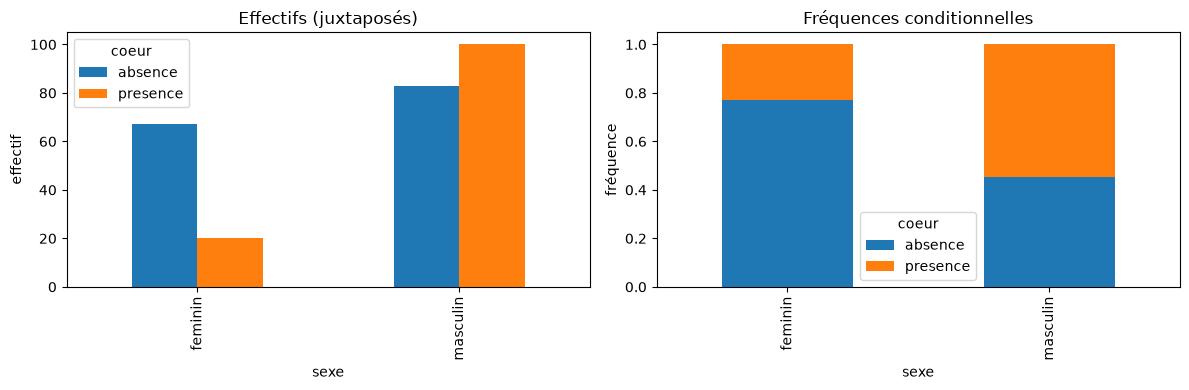

In [21]:
# --- Deux variables qualitatives : diagramme en bâtons ---  (R : barplot, beside=T)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Distribution jointe juxtaposée
cont.plot(kind='bar', ax=ax[0])
ax[0].set(title='Effectifs (juxtaposés)', xlabel='sexe', ylabel='effectif')

# Fréquences conditionnelles (empilées)
cond = cont.div(cont.sum(axis=1), axis=0)
cond.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].set(title='Fréquences conditionnelles', xlabel='sexe', ylabel='fréquence')
plt.tight_layout(); plt.show()

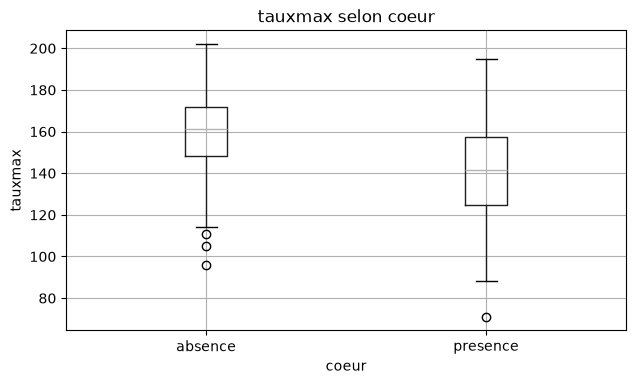

In [22]:
# --- Une qualitative et une quantitative : boxplot ---  (R : boxplot(quanti ~ quali))
dataset.boxplot(column='tauxmax', by='coeur', figsize=(7, 4))
plt.title('tauxmax selon coeur'); plt.suptitle(''); plt.ylabel('tauxmax')
plt.show()

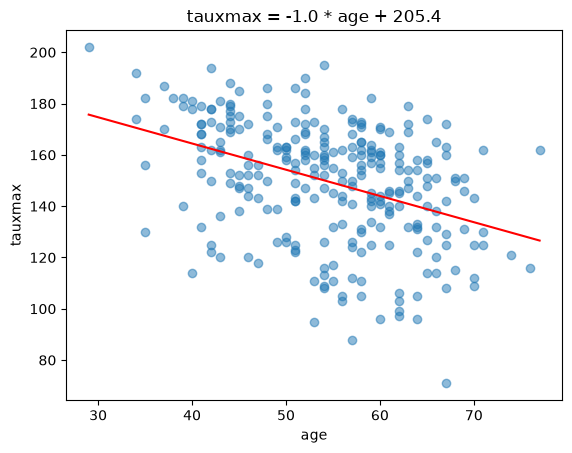

In [23]:
# --- Deux variables quantitatives : nuage de points + droite de régression ---
# (R : plot(data1, data2) ; abline(lm(data2 ~ data1)))
eq = f'tauxmax = {res.slope:.1f} * age + {res.intercept:.1f}'

plt.scatter(X, Y, alpha=0.5)
xs = np.array([X.min(), X.max()])
plt.plot(xs, res.slope * xs + res.intercept, color='red')
plt.xlabel('age'); plt.ylabel('tauxmax'); plt.title(eq)
plt.show()

## Interprétations (rappels)

- **Table de contingence** : un effectif beaucoup plus élevé dans une colonne peut signaler un échantillon non représentatif.
- **Fréquences conditionnelles** : décrivent la variation d'une variable pour une valeur fixée d'une autre.
- **Diagramme en bâtons** : barres à la même hauteur → indépendance ; trop de couches → mieux vaut regrouper / traiter en continu.
- **Effectifs cumulés** : croissance ~ linéaire sauf là où le pas augmente fortement.
- **Boxplot** : étendues très différentes → possibles valeurs aberrantes.
- **Nuage de points** : alignement → liaison ; amas → pas d'évolution particulière.
- **Covariance = 0** → indépendance. **Corrélation** proche de 0 → faible liaison ; proche de ±1 → forte liaison.
- ⚠️ Corrélation ≠ causalité.
- Pour décrire chaque variable indépendamment : utiliser les **distributions marginales**.